# Deforestación Perú — Descarga masiva Sentinel-2 (RGB + NIR)

**Curso:** MIA-07 Redes Neuronales y Aprendizaje Profundo — Sección B
**Proyecto final:** Detección de deforestación en imágenes satelitales

Este notebook baja imágenes **Sentinel-2** (bandas R, G, B, **NIR**) para cada polígono de deforestación del GeoJSON, usando el catálogo público **STAC earth-search (Element84)** — sin credenciales, leyendo COGs públicos en AWS.

Características:
- **4 bandas** (B04, B03, B02, B08, todas a 10 m) → permite RGB y NDVI.
- **Por lotes y reanudable**: un `sentinel_manifest.json` registra cada polígono ya bajado (o sin escena). Puedes parar y reanudar sin re-descargar.
- **Tracking por `row_id`** (índice de fila), porque `OBJECTID` tiene duplicados.

> Requisito: corre antes `01_descarga_y_exploracion.ipynb` para tener `deforestacion.geojson`. Si no está, este notebook lo baja igual.

## 1. Dependencias

In [1]:
# IMPORTANTE (Colab): tras instalar rasterio, reinicia el entorno
# (Entorno de ejecución -> Reiniciar) y vuelve a correr SIN esta celda.
!pip install -q rasterio pystac-client shapely tqdm geopandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 8.0 MB/s eta 0:00:00


## 2. Almacenamiento (Google Drive en Colab, o local)

Misma config que el notebook 01: en Colab montamos Drive y guardamos ahí (persiste). En local usa `./data`.

In [2]:
from pathlib import Path

try:
    from google.colab import drive
    drive.mount("/content/drive")
    IN_COLAB = True
    BASE_DIR = Path("/content/drive/MyDrive/deforestacion-peru")
except ImportError:
    IN_COLAB = False
    BASE_DIR = Path(".")

DATA_DIR = BASE_DIR / "data"
DATA_DIR.mkdir(parents=True, exist_ok=True)
print(f"Entorno: {'Colab + Drive' if IN_COLAB else 'Local'}")
print(f"Datos en: {DATA_DIR}")

Mounted at /content/drive
Entorno: Colab + Drive
Datos en: /content/drive/MyDrive/deforestacion-peru/data


## 3. Cargar etiquetas (GeoJSON)

In [3]:
import geopandas as gpd
import pandas as pd
import requests

GEOJSON_PATH = DATA_DIR / "deforestacion.geojson"
if not GEOJSON_PATH.exists():
    URL = "https://osmseed-dev.s3.amazonaws.com/test/deforestacion.geojson"
    print("GeoJSON no encontrado, descargando...")
    with requests.get(URL, stream=True, timeout=60) as r:
        r.raise_for_status()
        with open(GEOJSON_PATH, "wb") as f:
            for chunk in r.iter_content(chunk_size=1 << 20):
                f.write(chunk)

gdf = gpd.read_file(GEOJSON_PATH)
gdf["FESATB_dt"] = pd.to_datetime(gdf["FESATB"], errors="coerce")
print(f"Polígonos: {len(gdf):,} | OBJECTID únicos: {gdf['OBJECTID'].nunique():,}")

GeoJSON no encontrado, descargando...
Polígonos: 9,910 | OBJECTID únicos: 9,712


## 4. Configuración de descarga y manifest

`download_rgbn` baja las 4 bandas de un polígono y guarda un GeoTIFF. El manifest (`sentinel_manifest.json`) registra **éxitos y fallos** (sin escena), para que al reanudar no se repita el trabajo.

In [4]:
import json
import time
import numpy as np
import rasterio
from datetime import datetime, timedelta
from rasterio.windows import from_bounds
from rasterio.warp import transform_bounds
from pystac_client import Client

STAC_URL   = "https://earth-search.aws.element84.com/v1"
COLLECTION = "sentinel-2-l2a"
BANDS      = ["red", "green", "blue", "nir"]   # B04, B03, B02, B08 (10 m)

# --- DATASET DE DETECCIÓN DE CAMBIO (before/after) --------------------------
# Carpeta y manifest NUEVOS, separados del set single-image viejo. Por cada
# polígono bajamos DOS imágenes del mismo bbox: una cerca de FESATA (antes,
# bosque en pie) y otra cerca de FESATB (después, ya clareado). 4 bandas c/u.
IMG_DIR       = DATA_DIR / "sentinel_cd"
MANIFEST_PATH = DATA_DIR / "sentinel_manifest_cd.json"
IMG_DIR.mkdir(parents=True, exist_ok=True)

def is_valid_tif(path):
    """True solo si el GeoTIFF existe y tiene 4 bandas (R,G,B,NIR)."""
    try:
        if not path or not Path(path).exists():
            return False
        with rasterio.open(path) as s:
            return s.count == 4
    except Exception:
        return False

def is_done(rec):
    """Hecho si no hay escena, o si AMBOS tif (antes y después) tienen 4 bandas."""
    if not rec:
        return False
    if rec.get("status") == "no_scene":
        return True
    if rec.get("status") != "ok":
        return False
    return is_valid_tif((rec.get("antes")   or {}).get("path")) and \
           is_valid_tif((rec.get("despues") or {}).get("path"))

def load_manifest():
    if MANIFEST_PATH.exists():
        return json.loads(MANIFEST_PATH.read_text())
    return {}

def save_manifest(m):
    tmp = MANIFEST_PATH.with_suffix(".json.tmp")
    tmp.write_text(json.dumps(m, indent=1, ensure_ascii=False))
    tmp.replace(MANIFEST_PATH)   # escritura atómica: no corrompe si se corta

_client = Client.open(STAC_URL)

def _search_least_cloud(bbox, start, end, max_cloud, retries):
    """Item Sentinel de MENOS nube en [start, end] sobre bbox, o None si no hay."""
    for attempt in range(retries + 1):
        try:
            search = _client.search(
                collections=[COLLECTION], bbox=list(bbox),
                datetime=f"{start}/{end}",
                query={"eo:cloud_cover": {"lt": max_cloud}}, max_items=15,
            )
            items = sorted(search.items(), key=lambda it: it.properties["eo:cloud_cover"])
            return items[0] if items else None
        except Exception:
            if attempt == retries:
                raise
            time.sleep(2 * (attempt + 1))

def _read_bbox(item, bbox):
    """Lee R,G,B,NIR del item recortado al bbox -> (bands, transform, crs, prof)."""
    bands, win_transform, src_crs, prof = [], None, None, None
    with rasterio.Env(AWS_NO_SIGN_REQUEST="YES"):
        for b in BANDS:
            with rasterio.open(item.assets[b].href) as src:
                l, bm, r, t = transform_bounds("EPSG:4326", src.crs, *bbox)
                win = from_bounds(l, bm, r, t, src.transform)
                bands.append(src.read(1, window=win))
                if win_transform is None:
                    win_transform = src.window_transform(win)
                    src_crs, prof = src.crs, src.profile
    return bands, win_transform, src_crs, prof

def _write_tif(out_path, bands, win_transform, src_crs, prof):
    prof = prof.copy()
    prof.update(count=4, dtype="uint16", driver="GTiff", compress="deflate",
                height=bands[0].shape[0], width=bands[0].shape[1],
                transform=win_transform, crs=src_crs)
    with rasterio.open(out_path, "w", **prof) as dst:
        for i, b in enumerate(bands):
            dst.write(b.astype("uint16"), i + 1)

def download_par(row_id, objectid, geometry, fesata, fesatb, manifest,
                 buffer_deg=0.005, window_days=90, max_cloud=30, retries=2):
    """Baja par ANTES (cerca FESATA) + DESPUÉS (cerca FESATB), 4 bandas c/u,
    mismo bbox. Reanudable por manifest. Marca 'no_scene' si falta una imagen
    sin nubes en una de las dos ventanas, o si las dos caen en CRS distintos
    (par mal registrado: en change detection eso fabrica cambio falso)."""
    key = str(int(row_id))
    rec = manifest.get(key)
    if is_done(rec):
        return rec

    minx, miny, maxx, maxy = geometry.bounds
    bbox = (minx - buffer_deg, miny - buffer_deg, maxx + buffer_deg, maxy + buffer_deg)

    da = datetime.strptime(str(fesata)[:10].replace("-", "/"), "%Y/%m/%d")
    db = datetime.strptime(str(fesatb)[:10].replace("-", "/"), "%Y/%m/%d")
    # ventana ANTES: solo hacia atrás de FESATA -> garantiza bosque en pie
    a_start = (da - timedelta(days=window_days)).strftime("%Y-%m-%d")
    a_end   = da.strftime("%Y-%m-%d")
    # ventana DESPUÉS: solo hacia adelante de FESATB -> garantiza ya clareado
    b_start = db.strftime("%Y-%m-%d")
    b_end   = (db + timedelta(days=window_days)).strftime("%Y-%m-%d")

    it_a = _search_least_cloud(bbox, a_start, a_end, max_cloud, retries)
    it_b = _search_least_cloud(bbox, b_start, b_end, max_cloud, retries)
    if it_a is None or it_b is None:
        falta = ",".join([t for t, it in (("antes", it_a), ("despues", it_b)) if it is None])
        rec = {"row_id": key, "objectid": str(int(objectid)),
               "status": "no_scene", "falta": falta}
        manifest[key] = rec
        return rec

    # leer las dos ANTES de escribir, para validar mismo CRS (mismo grid)
    read = {}
    for tag, item in (("A", it_a), ("B", it_b)):
        read[tag] = (item, *_read_bbox(item, bbox))   # (item, bands, wt, crs, prof)
    if str(read["A"][3]) != str(read["B"][3]):
        rec = {"row_id": key, "objectid": str(int(objectid)),
               "status": "no_scene", "falta": "crs_mismatch"}
        manifest[key] = rec
        return rec

    out = {}
    for tag, (item, bands, wt, crs, prof) in read.items():
        fecha = str(item.datetime)[:10].replace("-", "")
        out_path = IMG_DIR / f"s2_{key}_{tag}_{fecha}.tif"
        _write_tif(out_path, bands, wt, crs, prof)
        out[tag] = {"stac_item": item.id, "datetime": str(item.datetime)[:10],
                    "cloud": round(float(item.properties["eo:cloud_cover"]), 1),
                    "path": str(out_path)}

    rec = {
        "row_id": key, "objectid": str(int(objectid)),
        "bbox": [round(v, 5) for v in bbox],
        "antes": out["A"], "despues": out["B"],
        # campos top-level por compatibilidad con 03 (alinea la máscara al grid
        # de la imagen "después", que comparte bbox con "antes") y con el split:
        "path": out["B"]["path"], "stac_item": out["B"]["stac_item"],
        "datetime": out["B"]["datetime"], "status": "ok",
    }
    manifest[key] = rec
    return rec

## 4b. Filtro por overlap (datos limpios desde la descarga)

Antes bajábamos todo y filtrábamos los solapes en `04`. Ahora el filtro vive **aquí**: como el bbox se calcula desde la geometría sin descargar, **no bajamos** polígonos que se encimen más de `OVERLAP_MAX` (20%) con los ya elegidos. El dataset queda limpio desde el origen, sin gastar descarga ni espacio en imágenes redundantes.

In [5]:
# --- Thinning por overlap (filtra ANTES de descargar) -----------------------
# El bbox de cada polígono se conoce desde la geometría, sin descargar nada.
# Así evitamos bajar imágenes que se encimen demasiado con las que ya tenemos:
# misma tierra repetida = redundancia + el modelo sobreaprende esa zona.
# "Overlap" = área de intersección / área del bbox más chico (qué fracción del
# recorte menor queda tapada por uno ya elegido). Permitir overlaps chicos
# (<OVERLAP_MAX) conserva vecinos que solo se rozan -> más variedad espacial.
OVERLAP_MAX = 0.20   # descarta si se encima MÁS de 20% con un bbox ya elegido

def poly_bbox(geometry, buffer_deg=0.005):
    """Mismo bbox que usa download_rgbn (bounds del polígono + buffer)."""
    minx, miny, maxx, maxy = geometry.bounds
    return (minx - buffer_deg, miny - buffer_deg, maxx + buffer_deg, maxy + buffer_deg)

def _inter(a, b):
    ix = max(0.0, min(a[2], b[2]) - max(a[0], b[0]))
    iy = max(0.0, min(a[3], b[3]) - max(a[1], b[1]))
    return ix * iy

def _area(a):
    return (a[2] - a[0]) * (a[3] - a[1])

def overlaps_too_much(bb, kept_bboxes, thr=OVERLAP_MAX):
    """True si bb se encima >thr con algún bbox ya elegido (área menor)."""
    ab = _area(bb)
    for kb in kept_bboxes:
        I = _inter(bb, kb)
        if I > 0 and I / min(ab, _area(kb)) > thr:
            return True
    return False

## 4c. Limpieza de Drive (opcional)

Deja en Drive **solo lo que el modelo usa**. Calcula el set a conservar (thinning por overlap sobre el manifest) y luego **escanea las carpetas físicas** `sentinel_rgbn/` y `masks/`: borra todo `.tif` que no esté en ese set — redundantes por overlap, huérfanos sin registro y restos de corridas viejas.

Corre en **dry-run** primero (`CONFIRMAR_LIMPIEZA = False`) para ver cuántos archivos y MB liberaría; recién pon `True` para borrar. Tiene una guardia que aborta si el set a conservar sale sospechosamente chico.

In [6]:
# --- LIMPIEZA: deja en Drive SOLO lo que se usa -----------------------------
# OJO: corre esta celda DESPUÉS de la descarga. Con manifest vacío no hace nada.
# 1) Calcula el set a conservar: thinning por overlap sobre los `ok` del
#    manifest -> keep_ids (~sin solapes >OVERLAP_MAX).
# 2) ESCANEA las carpetas físicas (sentinel_cd/ y masks_cd/) y borra TODO .tif
#    cuyo row_id no esté en keep_ids: redundantes por overlap, huérfanos, etc.
# Dry-run por defecto. Determinista (orden por row_id).
CONFIRMAR_LIMPIEZA = False   # <- ponlo en True para borrar de verdad

import re
MASK_DIR = DATA_DIR / "masks_cd"
manifest = load_manifest()

# 1) set a conservar
oks = sorted([r for r in manifest.values() if r.get("status") == "ok" and r.get("bbox")],
             key=lambda r: int(r["row_id"]))

if len(oks) == 0:
    print("Manifest CD vacío (aún no hay descargas ok). "
          "Corre primero la celda de descarga; la limpieza es opcional y va después.")
else:
    keep_ids, kept_bboxes = set(), []
    for r in oks:
        bb = tuple(r["bbox"])
        if not overlaps_too_much(bb, kept_bboxes):
            keep_ids.add(str(r["row_id"]))
            kept_bboxes.append(bb)

    # GUARDIA: si keep sale chico, abortamos (evita vaciar todo el Drive).
    assert len(keep_ids) >= 10, f"keep_ids demasiado chico ({len(keep_ids)}). Revisa el manifest."
    print(f"ok en manifest: {len(oks)} | a conservar tras thinning: {len(keep_ids)}")

    # 2) escaneo físico de las carpetas.
    # Imágenes: s2_{rid}_A_{fecha}.tif y s2_{rid}_B_{fecha}.tif -> rid
    # Máscaras: mask_{rid}.tif -> rid
    RID_IMG  = re.compile(r"^s2_(\d+)_[AB]_\d+\.tif$")
    RID_MASK = re.compile(r"^mask_(\d+)\.tif$")
    def scan(folder, rgx):
        keepf, dropf = [], []
        if not folder.exists():
            return keepf, dropf
        for f in sorted(folder.glob("*.tif")):
            m = rgx.search(f.name)
            rid = m.group(1) if m else None
            (keepf if rid in keep_ids else dropf).append(f)
        return keepf, dropf

    img_keep, img_drop = scan(IMG_DIR, RID_IMG)
    msk_keep, msk_drop = scan(MASK_DIR, RID_MASK)
    drop_files = img_drop + msk_drop
    mb = sum(f.stat().st_size for f in drop_files) / 1e6

    print(f"sentinel_cd/  conservar {len(img_keep):4d} | borrar {len(img_drop):4d}")
    print(f"masks_cd/     conservar {len(msk_keep):4d} | borrar {len(msk_drop):4d}")
    print(f"espacio a liberar: {mb:.0f} MB ({mb/1000:.2f} GB)")
    for f in (img_drop[:3] + msk_drop[:3]):
        print("  ej:", f.name)

    if not CONFIRMAR_LIMPIEZA:
        print("CONFIRMAR_LIMPIEZA=False -> dry-run, no se borró nada.")
    else:
        freed = 0
        for f in drop_files:
            try:
                freed += f.stat().st_size
                f.unlink()
            except FileNotFoundError:
                pass
        # saca del manifest los `ok` que ya no se conservan
        for r in oks:
            if str(r["row_id"]) not in keep_ids:
                manifest.pop(str(r["row_id"]), None)
        save_manifest(manifest)
        print(f"Borrados {len(drop_files)} archivos | liberados {freed/1e6:.0f} MB")
        print(f"Quedan: sentinel_cd={len(list(IMG_DIR.glob('*.tif')))} | "
              f"masks_cd={len(list(MASK_DIR.glob('*.tif'))) if MASK_DIR.exists() else 0}")

Manifest CD vacío (aún no hay descargas ok). Corre primero la celda de descarga; la limpieza es opcional y va después.


## 5. Descarga masiva por lotes

Recorremos **todos los polígonos únicos** (dedup por `OBJECTID`, ya que los duplicados son la misma geometría → misma imagen). Guardamos el manifest cada `SAVE_EVERY` items, así si se corta Colab no pierdes el avance.

Ajusta `MAX_ITEMS` para una prueba (p.ej. 50) o `None` para todo.

In [ ]:
import json
import threading
from tqdm.auto import tqdm
from concurrent.futures import ThreadPoolExecutor, as_completed

MAX_ITEMS  = 500     # None = todos los polígonos con ambas fechas (6298)
WORKERS    = 12      # descargas en paralelo (I/O-bound -> threads ayudan mucho)
SAVE_EVERY = 25      # guarda manifest cada N pares terminados

# 1) Candidatos: solo polígonos con AMBAS fechas (sin "antes" no hay par).
targets = gdf.drop_duplicates(subset="OBJECTID")
targets = targets[targets["FESATA"].notna() & targets["FESATB"].notna()]
print(f"Polígonos con ambas fechas: {len(targets)}")
if MAX_ITEMS:
    targets = targets.sample(n=min(MAX_ITEMS, len(targets)), random_state=None)

manifest = load_manifest()

# 2) THINNING PREVIO (solo geometría, sin descargar) -> lista fija a bajar.
#    Determinista y secuencial (rápido). Así desacoplamos el thinning con estado
#    de la descarga, que sí podemos paralelizar. Semilla = bboxes ya ok.
kept_bboxes = [tuple(r["bbox"]) for r in manifest.values()
               if r.get("status") == "ok" and r.get("bbox")]
tasks, n_skip, n_overlap = [], 0, 0
for row_id, row in targets.iterrows():
    key = str(int(row_id))
    if is_done(manifest.get(key)):
        n_skip += 1
        continue
    bb = poly_bbox(row.geometry)
    if overlaps_too_much(bb, kept_bboxes):
        n_overlap += 1
        continue
    kept_bboxes.append(bb)   # reserva el espacio para que el resto no se encime
    tasks.append((key, row["OBJECTID"], row.geometry, row["FESATA"], row["FESATB"]))

print(f"A descargar: {len(tasks)} | ya estaban: {n_skip} | saltados overlap: {n_overlap}")

# 3) DESCARGA PARALELA con ThreadPool. El manifest es un dict compartido; en
#    CPython setitem es atómico (GIL). Para guardar sin choque, snapshot con
#    reintento y contadores bajo lock.
lock = threading.Lock()
counts = {"ok": 0, "none": 0, "err": 0}

def _safe_save():
    while True:
        try:
            snap = dict(manifest); break          # copia atómica; reintenta si cambia
        except RuntimeError:
            pass
    tmp = MANIFEST_PATH.with_suffix(".json.tmp")
    tmp.write_text(json.dumps(snap, indent=1, ensure_ascii=False))
    tmp.replace(MANIFEST_PATH)

def work(t):
    key, oid, geom, fa, fb = t
    try:
        rec = download_par(key, oid, geom, fa, fb, manifest)
        k = "ok" if rec.get("status") == "ok" else "none"
    except Exception as e:
        manifest[key] = {"row_id": key, "objectid": str(int(oid)),
                         "status": "error", "error": str(e)[:200]}
        k = "err"
    with lock:
        counts[k] += 1
    return k

done = 0
with ThreadPoolExecutor(max_workers=WORKERS) as ex:
    futs = [ex.submit(work, t) for t in tasks]
    pbar = tqdm(as_completed(futs), total=len(futs), desc=f"Sentinel-2 par A/B (x{WORKERS})")
    for _ in pbar:
        done += 1
        if done % SAVE_EVERY == 0:
            _safe_save()
        pbar.set_postfix(**counts)

_safe_save()
print(f"\nListo. ok={counts['ok']}  sin_par={counts['none']}  error={counts['err']}  "
      f"(ya estaban {n_skip}, overlap {n_overlap})")
print(f"Total en manifest: {len(manifest)} | tif en disco: {len(list(IMG_DIR.glob('*.tif')))} "
      f"(2 por par: A y B)")

Polígonos con ambas fechas: 6112


Sentinel-2 (par A/B):   0%|          | 0/500 [00:00<?, ?it/s]


Listo. ok=214  ya_estaban=0  saltados_overlap=121  sin_par=165  error=0
Total en manifest: 379 | tif en disco: 428 (2 por par: A y B)


## 6. Verificación: muestra de descargas (RGB + NDVI)

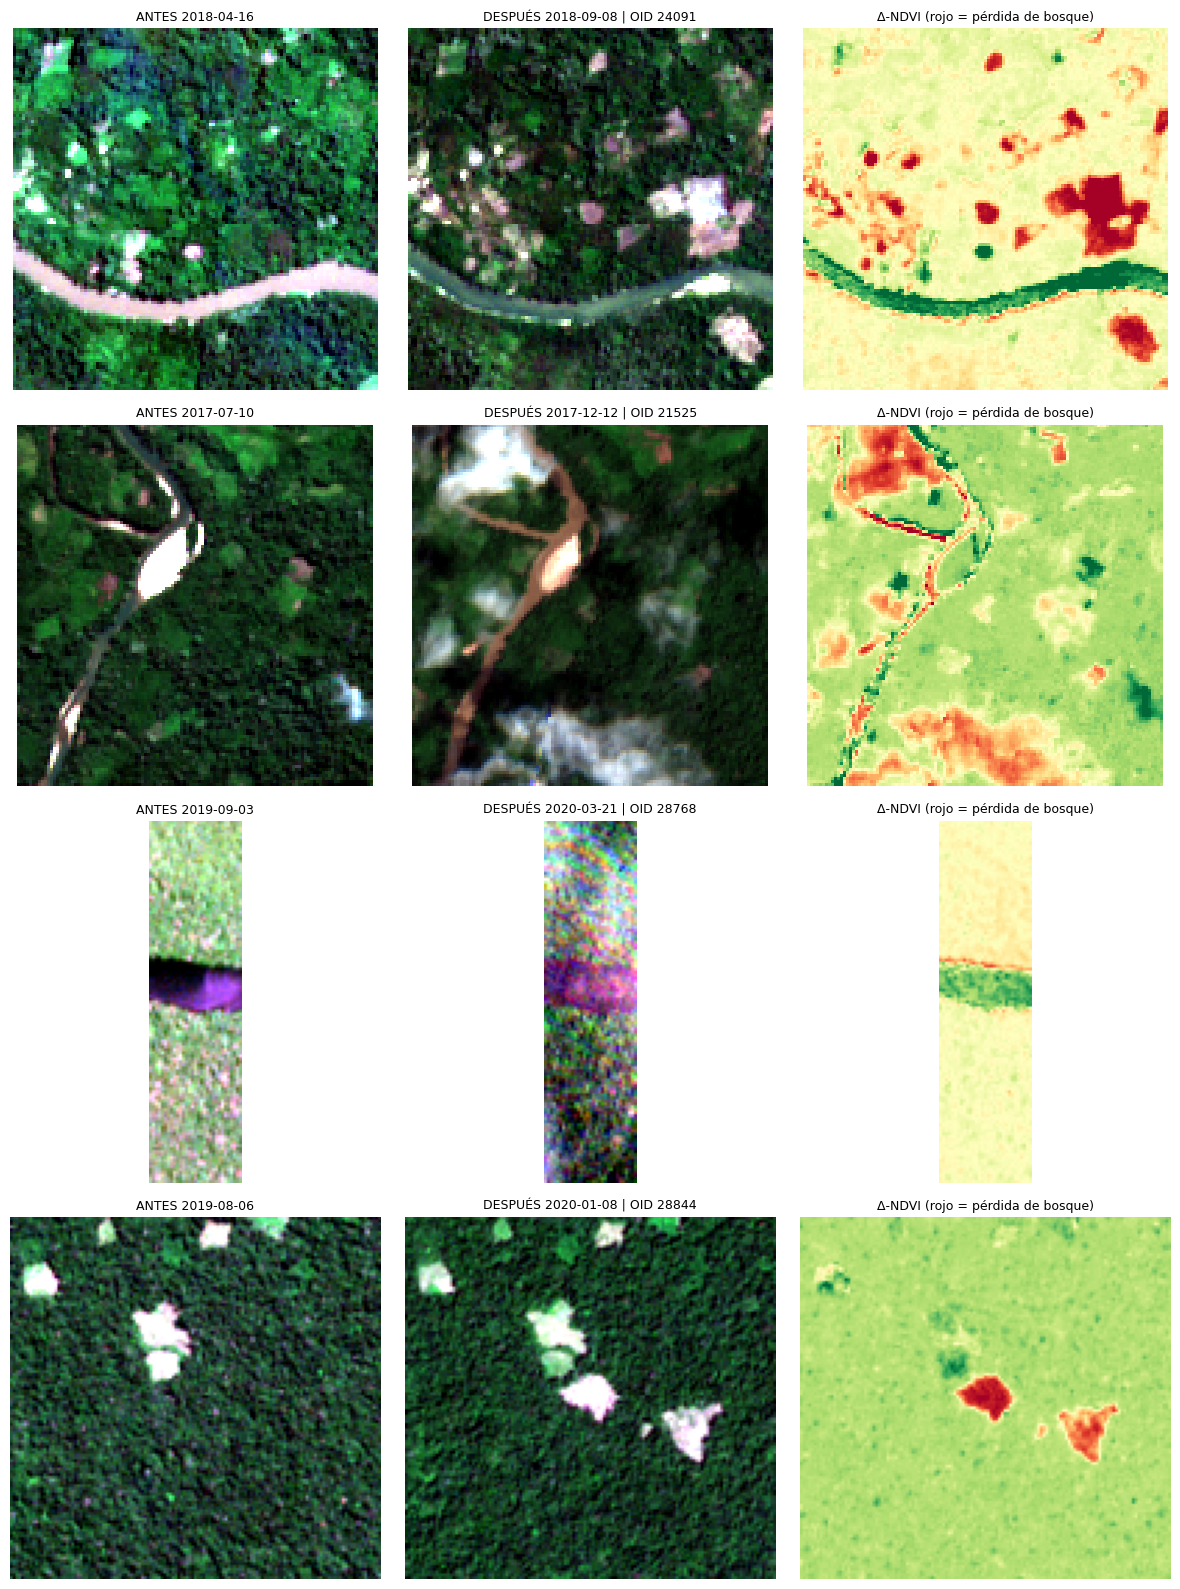

In [ ]:
import matplotlib.pyplot as plt

def stretch(a, lo=2, hi=98):
    a = a.astype("float32"); pl, ph = np.percentile(a, [lo, hi])
    return np.clip((a - pl) / (ph - pl + 1e-6), 0, 1)

def ndvi(arr):
    R, N = arr[0], arr[3]
    return (N - R) / (N + R + 1e-6)

# pares ok con ambas imágenes válidas
oks = [r for r in load_manifest().values() if is_done(r) and r.get("status") == "ok"][:4]
if oks:
    fig, axes = plt.subplots(len(oks), 3, figsize=(12, 4 * len(oks)))
    axes = np.atleast_2d(axes)
    for ax_row, rec in zip(axes, oks):
        with rasterio.open(rec["antes"]["path"]) as s:
            a = s.read().astype("float32")
        with rasterio.open(rec["despues"]["path"]) as s:
            b = s.read().astype("float32")
        ax_row[0].imshow(np.dstack([stretch(a[i]) for i in range(3)]))
        ax_row[0].set_title(f"ANTES {rec['antes']['datetime']}", fontsize=9)
        ax_row[1].imshow(np.dstack([stretch(b[i]) for i in range(3)]))
        ax_row[1].set_title(f"DESPUÉS {rec['despues']['datetime']} | OID {rec['objectid']}", fontsize=9)
        # Δ-NDVI = NDVI_antes - NDVI_despues. Alto (rojo) donde se perdió vegetación.
        dndvi = ndvi(a) - ndvi(b)
        ax_row[2].imshow(dndvi, cmap="RdYlGn_r", vmin=-0.3, vmax=0.6)
        ax_row[2].set_title("Δ-NDVI (rojo = pérdida de bosque)", fontsize=9)
        for ax in ax_row: ax.axis("off")
    plt.tight_layout(); plt.savefig(str(DATA_DIR / "sentinel_cd_muestra.png"), dpi=110, bbox_inches="tight"); plt.show()
else:
    print("Aún no hay pares ok (antes+después) en el manifest.")

## 7. Notas para el entrenamiento

- Cada GeoTIFF tiene 4 bandas (R, G, B, NIR) con CRS/transform reales → listo para recortar parches 256×256 (`04_dataset_parches.ipynb`).
- En Colab, antes de entrenar copia `sentinel_rgbn/` de Drive a `/content` (lectura local rápida); no leas miles de parches directo de Drive.
- Para re-descargar un polígono marcado `no_scene` o `error`, bórralo del manifest y vuelve a correr la celda de descarga.
- Polígonos anteriores a ~2018 pueden no tener escena en el archivo COG → quedan `no_scene`. Es esperado.